# Imports

In [837]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import pydicom
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [838]:
#seed used for random
seed = 42
torch.manual_seed(seed)

# Loading measurement data

In [839]:
#read csv
df = pd.read_csv("../data/measurements.csv")

print(df.columns)

#drop unnecessary columns
df.drop(columns = ["Student Name", "Notes", "Unnamed: 23", "Unnamed: 24", "Unnamed: 25", "Unnamed: 26"], inplace = True)

print(df.columns)

print(len(df.columns.values))

Index(['Student Name', 'ID', 'L Medial Cortical Thickness',
       'L Lateral Cortical Thickness ', 'L Shaft Width',
       'L Femoral Head Diameter', 'L Horizontal Offset', 'L Vertical Offset',
       'L Femoral Neck Width', 'L Hip Axis Length',
       'L Femoral Neck Axis Length', 'L Femoral Neck-Shaft  Angle',
       'R Medial Cortical Thickness', 'R Lateral Cortical Thickness ',
       'R Shaft Width', 'R Femoral Head Diameter', 'R Horizontal Offset',
       'R Vertical Offset', 'R Femoral Neck Width', 'R Hip Axis Length',
       'R Femoral Neck Axis Length', 'R Femoral Neck-Shaft  Angle', 'Notes',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26'],
      dtype='object')
Index(['ID', 'L Medial Cortical Thickness', 'L Lateral Cortical Thickness ',
       'L Shaft Width', 'L Femoral Head Diameter', 'L Horizontal Offset',
       'L Vertical Offset', 'L Femoral Neck Width', 'L Hip Axis Length',
       'L Femoral Neck Axis Length', 'L Femoral Neck-Shaft  Angle',
       '

In [840]:
#get rid of images with na (only temporary for convenience)
df = df.dropna()

# Load image data (augmentation, datasets, and dataloaders)

In [841]:
#image directory
img_dir = "../data/box_images"

#train test split
train_test_split = 0.8

#batch size
train_batch_size = 128
test_batch_size = 8

#pixels to mm conversion (known)
pix_to_mm = 408 / 2400

#training scale factor
scale_factor = 0.1

#image size (pix)
img_width = int(2400 * scale_factor)
img_height = int(1920 * scale_factor)

In [842]:
#data augmentation settings
## rotation
rot_int = 30
rot_st = 0
rot_en = 360 - rot_int

##down scale
scale_int = 0.1
scale_st = 0.5
scale_en = 0.6 #TODO can change this, 0.6 was chosen so no matter what rotation, no part of image is cut off

In [843]:
#class for each data point: image path, rotation, scale, true values for measurements
class DataPoint:
    def __init__(self, img_dir, img_file, df, img_width, img_height, aug_rot = 0, aug_scale = 1):
        self.img_path = img_dir + '/' + img_file
        self.img_width = img_width
        self.img_height = img_height
        self.aug_rot = aug_rot
        self.aug_scale = aug_scale
        self.y = torch.from_numpy(df.loc[df['ID'] == img_file].drop(columns = 'ID').values.astype(np.float32)).reshape(-1)
    
    #apply augmentation, return augmented image and rescaled values for measurements
    def get_image(self):
        ds = pydicom.dcmread(self.img_path)
        img = ds.pixel_array

        img = torch.from_numpy(img).float()
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        img = img.unsqueeze(0).unsqueeze(0)

        #downscale image
        new_height = int(self.img_height * self.aug_scale)
        new_width = int(self.img_width * self.aug_scale)
        img = F.interpolate(img, size = (new_height, new_width), mode = 'bilinear', align_corners = False)

        #pad back to target size
        pad_height = self.img_height - new_height
        pad_width = self.img_width - new_width
        pad_u = pad_height // 2
        pad_d = pad_height - pad_u
        pad_l = pad_width // 2
        pad_r = pad_width - pad_l
        img = F.pad(img, (pad_l, pad_r, pad_u, pad_d), mode = 'constant', value = 0)

        #rotate image
        img = TF.rotate(img, angle = self.aug_rot, interpolation = TF.InterpolationMode.BILINEAR)

        #rescale all measurements so they are in terms of pixels, EXCEPT FOR ANGLES (measurements 9 and 19)
        y_aug = self.y.clone()
        y_aug[:9] *= self.aug_scale
        y_aug[10:19] *= self.aug_scale

        return img.squeeze(0), y_aug


In [844]:
class ImageDataset(Dataset):
    def __init__(self, data_points):
        self.data_points = data_points

    def __len__(self):
        return len(self.data_points)

    def __getitem__(self, idx):
        return self.data_points[idx].get_image()

In [845]:
#all images in directory
all_img_in_dir = [i for i in os.listdir(img_dir) if i.lower().endswith("dcm")]

#check all images in df are loaded (else throw error)
for i in df['ID'].values:
    if i not in all_img_in_dir:
        raise SystemError(f'Directory is missing images: {i}')
    
#load only images in the df
all_img = [i for i in all_img_in_dir if i in df['ID'].values]
print(f'Images in use: {len(all_img)}/{len(all_img_in_dir)}')

#split train and test sets
all_idx = torch.randperm(len(all_img))
train_img = [all_img[i] for i in all_idx[:int(train_test_split * len(all_img))]]
test_img = [all_img[i] for i in all_idx[int(train_test_split * len(all_img)):]]

Images in use: 102/3094


In [846]:
#augmented training data in DataPoint class
train_data_points = []
for img_file in train_img:
    for aug_rot in np.arange(rot_st, rot_en + 1e-8, rot_int):
        for aug_scale in np.arange(scale_st, scale_en + 1e-8, scale_int):
            train_data_points.append(DataPoint(img_dir, img_file, df, img_width, img_height, aug_rot, aug_scale))
print(f'Augmented training set size: {len(train_data_points)}')

#testing data in DataPoint class (no augmentation transformations applied)
test_data_points = []
for img_file in test_img:
    test_data_points.append(DataPoint(img_dir, img_file, df, img_width, img_height, 0, 1))

Augmented training set size: 1296


In [847]:
#training dataset and data loader
train_set = ImageDataset(train_data_points)
train_loader = DataLoader(train_set, batch_size = train_batch_size, shuffle = True)

#testing dataset and data loader
test_set = ImageDataset(test_data_points)
test_loader = DataLoader(test_set, batch_size = test_batch_size, shuffle = False)

torch.Size([1, 192, 240])
torch.Size([128, 20])


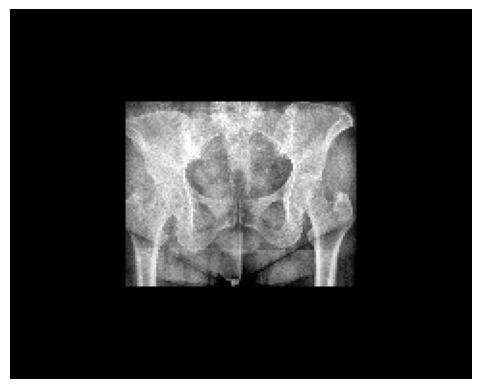

In [848]:
#quick test
for imgs, ys in train_loader:
    print(imgs[0].shape)
    print(ys.shape)
    plt.imshow(imgs[0].squeeze(), cmap = 'gray')
    plt.axis('off')
    plt.show()
    break


# Model

In [849]:
#number of epochs
epoch_cnt = 20

#learning rate
learning_rate = 1e-3

In [850]:
#take points from one side (either left or right) and output the requested measurements
def one_side_points_to_measurements(points, pix_to_mm, scale_factor, device):
    #shape: (batch_size, 12)
    #[B_x, B_y, C_x, C_y, D_x, E_x, F_x, G_x, W_x, X_x, Y_x, Z_x]
    #  0    1    2    3    4    5    6    7    8    9   10   11
    #NOTE: A = (0,0) for simplicity. Training has no location data, meaning the loss function only relies on the relative position of points wrt A, WLOG. So we do not learn A and simply assume it is (0,0)

    eps = 1e-6
    line1y = lambda x : points[:, 1] / (points[:, 0] + eps) * x
    line2x = lambda y : (points[:, 5] - points[:, 2]) / (line1y(points[:, 5]) - points[:, 3] + eps) * (y - points[:, 3]) + points[:, 2]
    a_point = torch.zeros(points.shape[0]).to(device)

    all_x_y = [None for _ in range(12)]
    all_x_y[0] = torch.stack([a_point, a_point], dim = -1)
    for i in range(1, 3):
        all_x_y[i] = torch.stack([points[:, 2 * i - 2], points[:, 2 * i - 1]], dim = -1)
    for i in range(3, 7):
        all_x_y[i] = torch.stack([points[:, i + 1], line1y(points[:, i + 1])], dim = -1)
    for i in range(7, 11):
        all_x_y[i] = torch.stack([points[:, i + 1], points[:, 3]], dim = -1)
    all_x_y[11] = torch.stack([line2x(a_point), a_point], dim = -1)
    
    all_points = torch.stack(all_x_y, dim = 1)
    #[A, B, C, D, E, F, G, W, X, Y,  Z,  K]
    # 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11

    xdist = lambda ptidx1, ptidx2 : all_points[:, ptidx1, 0] - all_points[:, ptidx2, 0] #signed x distance
    ydist = lambda ptidx1, ptidx2 : all_points[:, ptidx1, 1] - all_points[:, ptidx2, 1] #signed y distance
    dist = lambda ptidx1, ptidx2 : torch.sqrt(xdist(ptidx1, ptidx2) ** 2 + ydist(ptidx1, ptidx2) ** 2) #total distance
    ang = lambda x1, y1, x2, y2 : torch.arccos((x1 * x2 + y1 * y2) / (torch.sqrt(x1 ** 2 + y1 ** 2) * torch.sqrt(x2 ** 2 + y2 ** 2) + eps)) * 180 / torch.pi #angle between two vectors

    y = [None for _ in range(10)]
    y[0] = pix_to_mm / scale_factor * dist(7, 8)
    y[1] = pix_to_mm / scale_factor * dist(9, 10)
    y[2] = pix_to_mm / scale_factor * dist(7, 10)
    y[3] = pix_to_mm / scale_factor * 2 * dist(0, 3)
    y[4] = pix_to_mm / scale_factor * dist(0, 11)
    y[5] = pix_to_mm / scale_factor * torch.abs(ydist(0, 2))
    y[6] = pix_to_mm / scale_factor * 2 * torch.sqrt(torch.abs(dist(0, 3) ** 2 - dist(0, 1) ** 2))
    y[7] = pix_to_mm / scale_factor * dist(5, 6)
    y[8] = pix_to_mm / scale_factor * dist(3, 6)
    y[9] = ang(xdist(4, 0), ydist(4, 0), xdist(4, 2), ydist(4, 2))

    return (torch.stack(y, dim = -1), all_points)

In [851]:
#compute left points and then right points
def all_points_to_measurements(points, pix_to_mm, scale_factor, device):
    #shape: (batch_size, 24)

    l_measurements, l_points = one_side_points_to_measurements(points[:, :12], pix_to_mm, scale_factor, device)
    r_measurements, r_points = one_side_points_to_measurements(points[:, 12:], pix_to_mm, scale_factor, device)

    return (torch.cat([l_measurements, r_measurements], dim = 1), torch.cat([l_points, r_points], dim = 1))

In [852]:
#plot points for debugging
def plot_points(points, color):
    if (points.shape[0] != 12 or points.shape[1] != 2):
        raise SystemError(f'Incorrect dimensions for points out: {points.shape}')
    
    plt.scatter(points[:, 0], points[:, 1], c = color)
    for i, label in enumerate(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'W', 'X', 'Y', 'Z', 'K']):
            x, y = points[i]
            plt.text(x + 0.5, y + 0.5, label)
    plt.show()

In [853]:
#model
class CNNModel(nn.Module):
    def __init__(self, img_width, img_height):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * (img_width // 8) * (img_height // 8), 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 24)
        )

    def forward(self, x):
        x = self.seq(x)
        return x

model = CNNModel(img_width, img_height)

In [854]:
#device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [855]:
#loss function
lossfn = nn.MSELoss()

In [856]:
#optimizer
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [857]:
for epoch in range(epoch_cnt):
    model.to(device)
    model.train()

    total_loss = 0
    
    for images, yvals in train_loader:
        images = images.to(device)
        yvals = yvals.to(device)

        ypred, ypoints = all_points_to_measurements(model(images), pix_to_mm, scale_factor, device)

        loss = lossfn(ypred, yvals)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # if epoch % 10 and epoch != epoch_cnt - 1: #only print every x epochs
    #     continue

    print(f'Epoch: {epoch}\n')
    print(f'Loss (in sample): {total_loss / len(train_set)}')

    total_loss = 0
    total_percent_err = torch.zeros(20).to(device)
    model.eval()
    for images, yvals in test_loader:
        images = images.to(device)
        yvals = yvals.to(device)

        ypred, ypoints = all_points_to_measurements(model(images), pix_to_mm, scale_factor, device)

        loss = lossfn(ypred, yvals)
        total_loss += loss.item()

        total_percent_err += torch.sum(torch.abs(yvals - ypred) / yvals, dim = 0)
    
    print(f'Loss (out sample): {total_loss / len(test_set)}\n')
    print(f'Percent error for each measurement (out sample):')
    for i in total_percent_err[:10]:
        print(f'{(i.item() / len(test_set)):.4f}', end = ' ')
    print()
    for i in total_percent_err[10:]:
        print(f'{(i.item() / len(test_set)):.4f}', end = ' ')

    print('\n===\n')            

Epoch: 0

Loss (in sample): 15.269158257378471
Loss (out sample): 603.397960844494

Percent error for each measurement (out sample):
0.6690 0.2763 0.8481 0.9461 0.9992 0.9253 0.6971 0.9550 0.9773 0.1695 
0.4718 0.5226 0.9717 0.9454 0.9727 0.9664 0.5763 0.9971 0.9764 0.1140 
===

Epoch: 1

Loss (in sample): 9.876271707040292
Loss (out sample): 466.40468052455356

Percent error for each measurement (out sample):
0.2305 0.3029 0.5014 0.6864 0.9961 0.7999 0.3974 0.8300 0.8586 0.1940 
0.2340 1.0676 0.6922 0.7017 0.9247 0.9493 0.1990 0.9085 0.8459 0.0402 
===

Epoch: 2

Loss (in sample): 5.868546803792317
Loss (out sample): 312.8071986607143

Percent error for each measurement (out sample):
0.5853 0.5370 0.4676 0.1915 0.9010 0.7259 0.2486 0.5994 0.6359 0.1225 
0.7717 0.6808 0.5085 0.3434 0.9509 0.9120 0.2287 0.7721 0.6950 0.0455 
===

Epoch: 3

Loss (in sample): 3.848467085096571
Loss (out sample): 292.59571475074404

Percent error for each measurement (out sample):
0.5858 0.6424 0.5767 0.45

tensor([[  0.0000,   0.0000],
        [ 10.6917,   3.8469],
        [-22.4240, -28.7105],
        [  9.1596,   3.2956],
        [-16.1026,  -5.7938],
        [ 15.7685,   5.6736],
        [-28.1297, -10.1212],
        [ -1.0219, -28.7105],
        [ -2.5454, -28.7105],
        [ 13.8410, -28.7105],
        [ 12.9950, -28.7105],
        [-14.5044,   0.0000],
        [  0.0000,   0.0000],
        [ 13.2500,  -0.4868],
        [-27.4880,  26.1953],
        [-10.7782,   0.3960],
        [-11.7614,   0.4321],
        [-16.8813,   0.6202],
        [ 29.6981,  -1.0911],
        [  6.6743,  26.1953],
        [  7.9297,  26.1953],
        [ -6.8168,  26.1953],
        [ -7.2280,  26.1953],
        [-11.4976,   0.0000]])


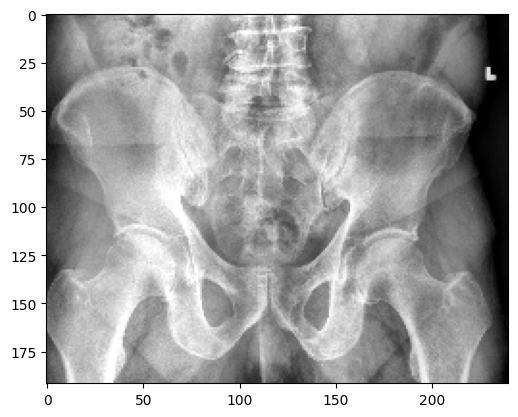

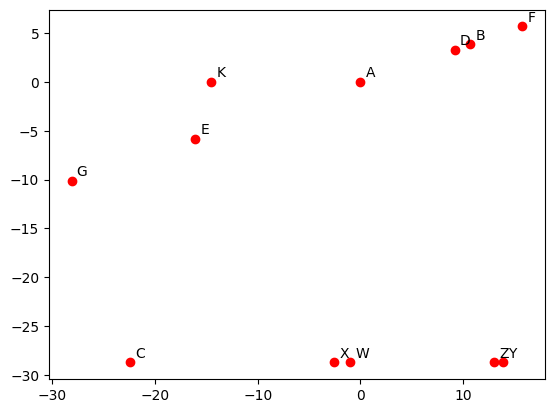

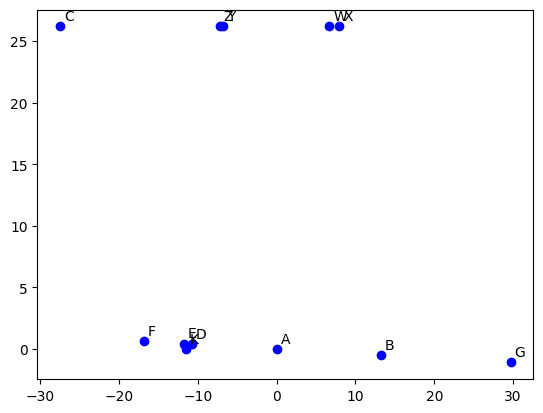

tensor([  2.5899,   1.4383,  23.8287,  33.0970,  24.6575,  48.8078,  19.9275,
         79.3104,  67.3702, 125.2101,   2.1343,   0.6990,  23.6339,  36.6706,
         19.5459,  44.5320,  26.2202,  79.2384,  68.8561, 123.5054],
       device='mps:0', grad_fn=<SelectBackward0>)
tensor([  6.6900,   5.4700,  42.2900,  61.8800,  50.1550,  91.9700,  43.8100,
        160.4750, 131.2200, 130.9050,   7.0650,   6.7050,  42.5850,  63.6850,
         50.0750,  98.6000,  44.7150, 163.3500, 130.1200, 128.5500],
       device='mps:0')
tensor([[  0.0000,   0.0000],
        [ 10.5358,   3.7938],
        [-22.2541, -28.3858],
        [  9.0646,   3.2640],
        [-15.9508,  -5.7437],
        [ 15.6112,   5.6214],
        [-27.8193, -10.0174],
        [ -0.9569, -28.3858],
        [ -2.4721, -28.3858],
        [ 13.7515, -28.3858],
        [ 12.8657, -28.3858],
        [-14.3518,   0.0000],
        [  0.0000,   0.0000],
        [ 13.0591,  -0.5145],
        [-27.2228,  25.9631],
        [-10.6304,   0.4188

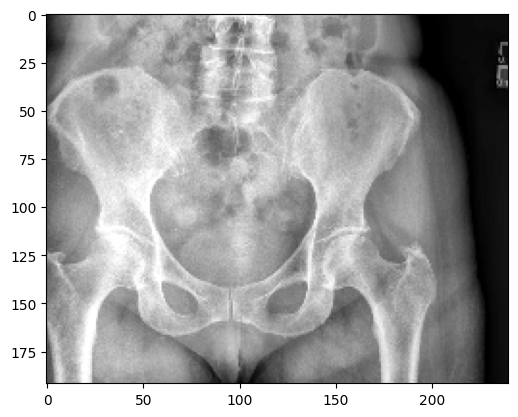

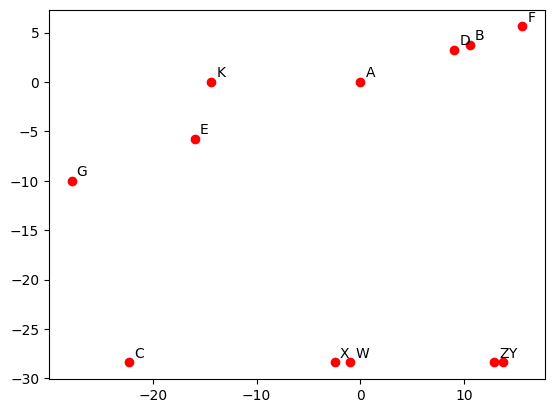

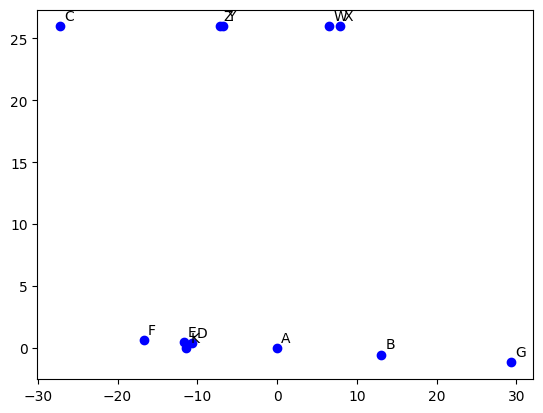

tensor([  2.5759,   1.5059,  23.4984,  32.7569,  24.3981,  48.2559,  19.4051,
         78.4727,  66.6439, 125.3599,   2.2316,   0.7031,  23.3520,  36.1715,
         19.3632,  44.1373,  25.8093,  78.2398,  67.9279, 123.6318],
       device='mps:0', grad_fn=<SelectBackward0>)
tensor([  6.1200,   6.9700,  37.4000,  51.5000,  43.6900,  73.1000,  35.4200,
        129.3000, 107.0800, 127.9200,   6.6300,   6.1200,  36.7200,  51.0600,
         43.6900,  81.0900,  35.1400, 132.8300, 109.6300, 132.5400],
       device='mps:0')
tensor([[  0.0000,   0.0000],
        [ 10.3698,   3.7441],
        [-22.1289, -28.0876],
        [  8.9694,   3.2385],
        [-15.7598,  -5.6903],
        [ 15.5263,   5.6060],
        [-27.5349,  -9.9418],
        [ -0.8759, -28.0876],
        [ -2.3547, -28.0876],
        [ 13.6910, -28.0876],
        [ 12.8094, -28.0876],
        [-14.1416,   0.0000],
        [  0.0000,   0.0000],
        [ 12.8257,  -0.5232],
        [-27.0314,  25.7233],
        [-10.4912,   0.4279

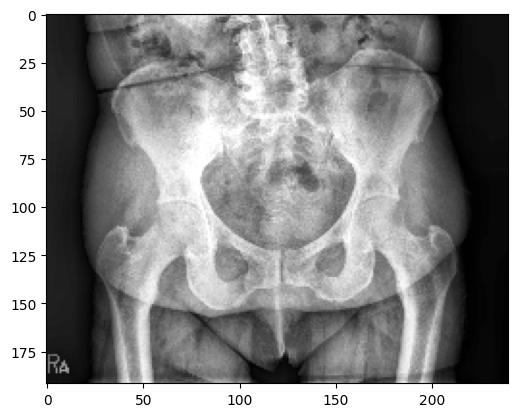

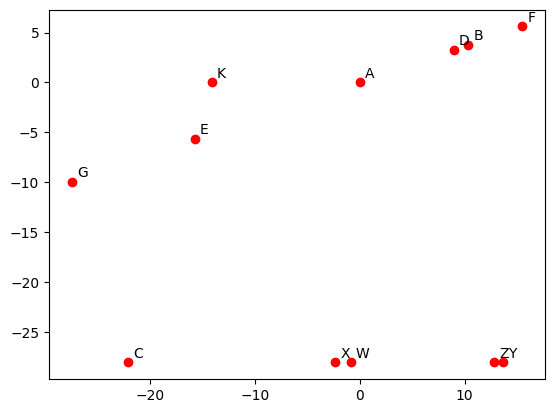

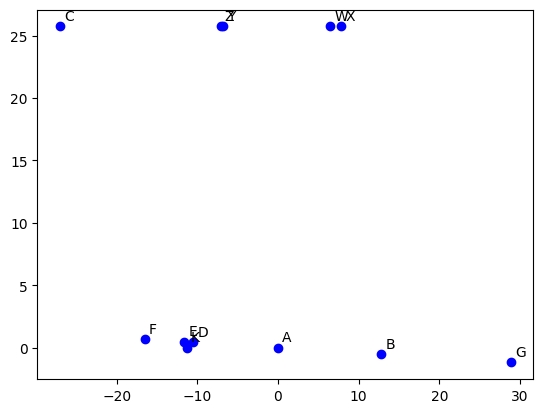

tensor([  2.5140,   1.4987,  23.2650,  32.4230,  24.0408,  47.7490,  18.8114,
         77.8296,  65.9785, 125.7270,   2.2893,   0.5881,  23.1210,  35.6998,
         19.2319,  43.7296,  25.1056,  77.2187,  66.9694, 123.7632],
       device='mps:0', grad_fn=<SelectBackward0>)
tensor([ 10.4800,   8.1100,  35.8200,  47.6900,  51.3600,  73.6700,  31.4100,
        117.2200, 105.2600, 123.1000,  12.1700,   7.1000,  35.1400,  48.2600,
         53.0500,  70.6200,  34.6700, 120.7200, 111.1500, 127.2000],
       device='mps:0')


In [858]:
model.to(device)
model.eval()
for images, yvals in test_loader:
    images = images.to(device)
    yvals = yvals.to(device)

    ypred, ypoints = all_points_to_measurements(model(images), pix_to_mm, scale_factor, device)

    loss = lossfn(ypred, yvals)
    total_loss += loss.item()

    total_percent_err += torch.sum(torch.abs(yvals - ypred) / yvals, dim = 0)

    cur_points = ypoints[0].detach().cpu()
    print(cur_points)

    plt.imshow(images[0].squeeze().cpu(), cmap = 'gray')
    plt.show()
    plot_points(cur_points[:12], 'r') #right side (left part of physical image)
    plot_points(cur_points[12:], 'b') #left side (right part of physical image)
    
    plt.show()

    print(ypred[0])
    print(yvals[0])